### `Feature Selection`

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
pd.set_option("display.max_columns", 60)

In [26]:
df = pd.read_csv("D:/CODING/Virtual_py/PROJECTS/real_estate_ml/backend/kolkata/kolkata_cleaned_v5.csv")

In [27]:
train_df = df.drop(columns = ["PRICE_PER_SQFT(INR)"])

In [28]:
train_df.head()

,PREFERENCE,DESCRIPTION,TRANSACT_TYPE,BEDROOM_NUM,AGE,TOTAL_FLOOR,PROP_NAME,PROP_HEADING,SECONDARY_TAGS,TOTAL_LANDMARK_COUNT,BALCONY_NUM,FLOOR_NUM,PRICE_Cr,AREA_SQFT,OWNTYPE_label,LATITUDE,LONGITUDE,Cooperative Society,Power of Attorney,Other,Leasehold,FACING_LABEL,FACING_label_North,FACING_label_North-East,FACING_label_North-West,FACING_label_Other,FACING_label_South,FACING_label_South-East,FACING_label_South-West,FACING_label_West,FURNISH_LABEL,FURNISH_label_Other,FURNISH_label_Semi-furnished,FURNISH_label_Unfurnished,PROPERTY_type,PROPERTY_TYPE_Independent/Builder Floor,PROPERTY_TYPE_Residential Apartment,PROPERTY_TYPE_Residential Land,CITY_LABELS,CITY_Kolkata East,CITY_Kolkata North,CITY_Kolkata South,CITY_Kolkata West,LANDMARK_DETAILS,CITY_NUM,LOCALITY
0,S,3bhk flat on the second floor of a four-Storey...,1.0,3.0,6,4.0,team taurus kabya,3 BHK Flat in Rajarhat,"['READY TO MOVE', 'RESALE', 'RERA | HIRA']",29.0,2.0,2.0,0.50,1287.0,Cooperative Society,22.629509,88.479623,1,0,0,0,East,0,0,0,0,0,0,0,0,Fully furnished,0,0,0,Residential Apartment,0,1,0,Kolkata East,1,0,0,0,"['ReligiousPlace', 'Hospital', 'OfficeComplex'...",28,Rajarhat
1,S,"3bhk, 2 bath, semi-Furnished, 7th floor (Of 15...",1.0,3.0,2,15.0,eden city maheshtala,3 BHK Flat in Maheshtala,"['READY TO MOVE', 'RESALE', 'RERA | HIRA']",8.0,1.0,7.0,0.45,1377.0,Cooperative Society,88.210954,22.493402,1,0,0,0,East,0,0,0,0,0,0,0,0,Other,1,0,0,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['MetroStation', 'Shopping', 'Connectivity', '...",27,Maheshtala
2,S,3bhk flat/apartment for sale in baisnabghata b...,1.0,2.0,3,3.0,baisnabghata,2 BHK Flat in Baishnabghata Bye Lane,"['READY TO MOVE', 'RESALE']",48.0,4.0,3.0,0.35,810.0,Cooperative Society,22.471111,88.372903,1,0,0,0,South-East,0,0,0,0,0,1,0,0,Other,1,0,0,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['MetroStation', 'ReligiousPlace', 'ATM', 'Hos...",27,Baishnabghata Bye Lane
3,S,This is your chance to own a 3 bhk residential...,1.0,3.0,5,3.0,moana by varada group,3 BHK Flat in Raja SC Mallick ROAD,"['UNDER CONSTRUCTION', 'RESALE']",50.0,1.0,1.0,0.75,1208.0,Cooperative Society,22.496720,88.370570,1,0,0,0,East,0,0,0,0,0,0,0,0,Fully furnished,0,0,0,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['ReligiousPlace', 'Hospital', 'Attraction']",27,Raja SC Mallick ROAD
4,S,2bhk flat/apartment for sale in lake gardens c...,1.0,2.0,3,5.0,lake gardens chs,2 BHK Flat in Lake Gardens,"['READY TO MOVE', 'RESALE']",50.0,0.0,0.0,0.50,827.0,Cooperative Society,22.505744,88.356716,1,0,0,0,North-West,0,0,1,0,0,0,0,0,Unfurnished,0,0,1,Residential Apartment,0,1,0,Kolkata South,0,0,1,0,"['MetroStation', 'ReligiousPlace', 'ATM', 'Hos...",27,Lake Gardens


In [29]:
# encoding data into ordinal (if we use linear models we need to do ohe)
from sklearn.preprocessing import OrdinalEncoder

data_label_encoded = train_df.copy()



categorical_cols = train_df.select_dtypes(include=["str"]).columns

for cols in categorical_cols:
    ore = OrdinalEncoder()
    data_label_encoded[cols] = ore.fit_transform(data_label_encoded[[cols]])
    print(ore.categories_)

# splitting into training and testin 
X_label = data_label_encoded.drop(columns = ["PRICE_Cr"])
y_label = data_label_encoded["PRICE_Cr"]

[array(['S'], dtype=object)]
[array(['1 bhk apartment for sale near em bypass kolkata. The apartment is in kalikapur, very near to ruchira apartment which is a promising investment destination in kolkata. This might be your chance to grab the best 1 bhk property for sale in kalikapur. The property is on floor 1 and the total number of floors is 4. This 1 bhk apartment is available at a reasonable price of rs 31.0 l.',
       '1 bhk flat is available in the promising locality of barasat, kolkata north. It is an spacious flat and is located on 3rd floor. Every single detail of the flat is carefully designed. The apartment is priced at rs. Rs 8.50.000/- Lac , it is a freehold property, with a super built-Up area of 391 sq.Ft. It has 1 bathroom(s). The flat comprises of 1 balcony(s). \nAdditional details :\nNo power backup is available.\nThe society has dedicated security guards for every tower.',
       '1 marble flooring,fully furnished made of green ply and century ply.Used hettich hing

In [31]:
X_label.head()

,PREFERENCE,DESCRIPTION,TRANSACT_TYPE,BEDROOM_NUM,AGE,TOTAL_FLOOR,PROP_NAME,PROP_HEADING,SECONDARY_TAGS,TOTAL_LANDMARK_COUNT,BALCONY_NUM,FLOOR_NUM,AREA_SQFT,OWNTYPE_label,LATITUDE,LONGITUDE,Cooperative Society,Power of Attorney,Other,Leasehold,FACING_LABEL,FACING_label_North,FACING_label_North-East,FACING_label_North-West,FACING_label_Other,FACING_label_South,FACING_label_South-East,FACING_label_South-West,FACING_label_West,FURNISH_LABEL,FURNISH_label_Other,FURNISH_label_Semi-furnished,FURNISH_label_Unfurnished,PROPERTY_type,PROPERTY_TYPE_Independent/Builder Floor,PROPERTY_TYPE_Residential Apartment,PROPERTY_TYPE_Residential Land,CITY_LABELS,CITY_Kolkata East,CITY_Kolkata North,CITY_Kolkata South,CITY_Kolkata West,LANDMARK_DETAILS,CITY_NUM,LOCALITY
0,0.0,248.0,1.0,3.0,6,4.0,1601.0,542.0,42.0,29.0,2.0,2.0,1287.0,0.0,22.629509,88.479623,1,0,0,0,0.0,0,0,0,0,0,0,0,0,0.0,0,0,0,2.0,0,1,0,1.0,1,0,0,0,208.0,28,284.0
1,0.0,275.0,1.0,3.0,2,15.0,415.0,489.0,42.0,8.0,1.0,7.0,1377.0,0.0,88.210954,22.493402,1,0,0,0,0.0,0,0,0,0,0,0,0,0,1.0,1,0,0,2.0,0,1,0,3.0,0,0,1,0,118.0,27,199.0
2,0.0,252.0,1.0,2.0,3,3.0,174.0,84.0,43.0,48.0,4.0,3.0,810.0,0.0,22.471111,88.372903,1,0,0,0,6.0,0,0,0,0,0,1,0,0,1.0,1,0,0,2.0,0,1,0,3.0,0,0,1,0,80.0,27,36.0
3,0.0,3801.0,1.0,3.0,5,3.0,819.0,540.0,45.0,50.0,1.0,1.0,1208.0,0.0,22.496720,88.370570,1,0,0,0,0.0,0,0,0,0,0,0,0,0,0.0,0,0,0,2.0,0,1,0,3.0,0,0,1,0,204.0,27,282.0
4,0.0,120.0,1.0,2.0,3,5.0,669.0,189.0,43.0,50.0,0.0,0.0,827.0,0.0,22.505744,88.356716,1,0,0,0,3.0,0,0,1,0,0,0,0,0,3.0,0,0,1,2.0,0,1,0,3.0,0,0,1,0,95.0,27,189.0


In [32]:
y_label.head()

0    0.50
1    0.45
2    0.35
3    0.75
4    0.50
Name: PRICE_Cr, dtype: float64

<Axes: >

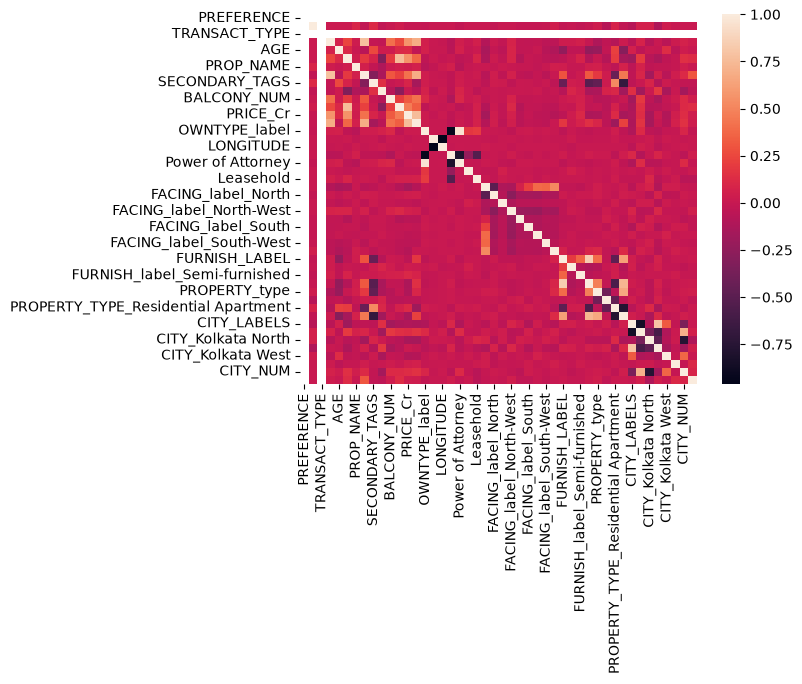

In [33]:
# correlation technique

sns.heatmap(data_label_encoded.corr())

In [34]:
fi_df1 = data_label_encoded.corr()["PRICE_Cr"].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,PRICE_Cr
0,DESCRIPTION,-0.008814
1,TRANSACT_TYPE,NaN
2,BEDROOM_NUM,0.565761
3,AGE,0.117228
4,TOTAL_FLOOR,0.562841
5,PROP_NAME,0.034424
6,PROP_HEADING,0.415491
7,SECONDARY_TAGS,0.084598
8,TOTAL_LANDMARK_COUNT,-0.002241
9,BALCONY_NUM,0.320771


In [36]:
# randomf forest technique -> embedded technique

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators = 100, random_state=42)
rf.fit(X_label, y_label)

fi_df2 = pd.DataFrame({
    "feature" : X_label.columns,
    "rf_importance" : rf.feature_importances_
}).sort_values(by = "rf_importance", ascending=False)

fi_df2

,feature,rf_importance
12,AREA_SQFT,0.649266
7,PROP_HEADING,0.103384
5,TOTAL_FLOOR,0.061638
14,LATITUDE,0.050377
15,LONGITUDE,0.028891
9,TOTAL_LANDMARK_COUNT,0.015258
42,LANDMARK_DETAILS,0.012338
6,PROP_NAME,0.012078
8,SECONDARY_TAGS,0.010056
1,DESCRIPTION,0.007698


In [37]:
# gradient boosting technique -> embedded technique

from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_label, y_label)

fi_df3 = pd.DataFrame({
    "feature" : X_label.columns,
    "gb_importance" : gb.feature_importances_
}).sort_values(by = "gb_importance", ascending=False) 

fi_df3

,feature,gb_importance
12,AREA_SQFT,0.669587
5,TOTAL_FLOOR,0.086870
7,PROP_HEADING,0.085665
14,LATITUDE,0.043144
15,LONGITUDE,0.041192
9,TOTAL_LANDMARK_COUNT,0.016249
35,PROPERTY_TYPE_Residential Apartment,0.010482
8,SECONDARY_TAGS,0.007478
3,BEDROOM_NUM,0.006629
42,LANDMARK_DETAILS,0.005296


In [38]:
# Permutation importance
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split    

X_train, X_test, y_train, y_test = train_test_split(X_label, y_label, test_size=0.2, random_state = 4)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state = 42)

fi_df4 = pd.DataFrame({
    "feature" : X_label.columns,
    "perm_importance" : perm_importance.importances_mean
}).sort_values(by = "perm_importance", ascending=False) 

fi_df4

,feature,perm_importance
12,AREA_SQFT,1.065706e+00
7,PROP_HEADING,1.204535e-01
5,TOTAL_FLOOR,1.111680e-01
14,LATITUDE,5.301975e-02
15,LONGITUDE,3.271525e-02
9,TOTAL_LANDMARK_COUNT,1.501380e-02
8,SECONDARY_TAGS,9.830407e-03
42,LANDMARK_DETAILS,8.692253e-03
6,PROP_NAME,6.179365e-03
35,PROPERTY_TYPE_Residential Apartment,3.757338e-03


In [39]:
# LASSO
# though we used ore linear models are not that much reliable

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

lasso = Lasso(alpha = 0.01, random_state=42)
lasso.fit(X_scaled, y_label)

fi_df5 = pd.DataFrame({
    "feature" : X_label.columns,
    "lasso_coeff" : lasso.coef_
}).sort_values(by = "lasso_coeff", ascending=False) 

fi_df5

,feature,lasso_coeff
12,AREA_SQFT,0.470946
5,TOTAL_FLOOR,0.190205
9,TOTAL_LANDMARK_COUNT,0.043490
40,CITY_Kolkata South,0.025835
4,AGE,0.013713
3,BEDROOM_NUM,0.012317
31,FURNISH_label_Semi-furnished,0.005308
15,LONGITUDE,0.003796
1,DESCRIPTION,-0.000000
8,SECONDARY_TAGS,-0.000000


In [40]:
# RFE

from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
12,AREA_SQFT,0.650393
7,PROP_HEADING,0.105807
5,TOTAL_FLOOR,0.060315
14,LATITUDE,0.048330
15,LONGITUDE,0.027692
9,TOTAL_LANDMARK_COUNT,0.014865
6,PROP_NAME,0.012420
42,LANDMARK_DETAILS,0.011340
8,SECONDARY_TAGS,0.010251
11,FLOOR_NUM,0.007490


In [41]:
# linear regression weights
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
12,AREA_SQFT,4.853687e-01
5,TOTAL_FLOOR,1.944019e-01
35,PROPERTY_TYPE_Residential Apartment,5.971998e-02
43,CITY_NUM,5.269780e-02
3,BEDROOM_NUM,5.086019e-02
9,TOTAL_LANDMARK_COUNT,5.023199e-02
15,LONGITUDE,4.029228e-02
14,LATITUDE,2.692100e-02
40,CITY_Kolkata South,2.579900e-02
4,AGE,2.080005e-02


In [42]:
# merge the dataframes to compare
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').set_index('feature')
final_fi_df

,PRICE_Cr,rf_importance,gb_importance,perm_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,,
DESCRIPTION,-0.008814,0.007698,0.000380,1.262255e-03,-0.000000,0.007408,-2.829045e-03
TRANSACT_TYPE,NaN,0.000000,0.000000,0.000000e+00,0.000000,0.000000,5.551115e-17
BEDROOM_NUM,0.565761,0.001375,0.006629,1.614225e-03,0.012317,0.001430,5.086019e-02
AGE,0.117228,0.005900,0.002917,2.477342e-03,0.013713,0.006871,2.080005e-02
TOTAL_FLOOR,0.562841,0.061638,0.086870,1.111680e-01,0.190205,0.060315,1.944019e-01
PROP_NAME,0.034424,0.012078,0.003713,6.179365e-03,0.000000,0.012420,1.643476e-03
PROP_HEADING,0.415491,0.103384,0.085665,1.204535e-01,-0.000000,0.105807,-4.803650e-02
SECONDARY_TAGS,0.084598,0.010056,0.007478,9.830407e-03,-0.000000,0.010251,-1.608459e-02
TOTAL_LANDMARK_COUNT,-0.002241,0.015258,0.016249,1.501380e-02,0.043490,0.014865,5.023199e-02


In [43]:
# normalizing the data
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis = 0), axis = 1)


In [45]:
final_fi_df[['rf_importance','gb_importance','perm_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)

feature
AREA_SQFT                                  0.676535
PROP_HEADING                               0.094537
TOTAL_FLOOR                                0.071423
LATITUDE                                   0.044628
LONGITUDE                                  0.030099
TOTAL_LANDMARK_COUNT                       0.014188
LANDMARK_DETAILS                           0.008746
SECONDARY_TAGS                             0.008645
PROP_NAME                                  0.008121
PROPERTY_TYPE_Residential Apartment        0.006268
FLOOR_NUM                                  0.005298
AGE                                        0.004350
DESCRIPTION                                0.004090
LOCALITY                                   0.004048
BEDROOM_NUM                                0.002638
PROPERTY_TYPE_Residential Land             0.002212
BALCONY_NUM                                0.001902
FACING_LABEL                               0.001833
PROPERTY_type                              0.001659
CITY

> preparing model to judge score whether deleting a feature will improve the model's performance or not.        


cols to remove = ["FURNISH_label_Unfurnished", "Cooperative Society", "OWNTYPE_label" ,"FACING_label_South-West", "Power of Attorney", "PROPERTY_TYPE_Independent/Builder Floor","Leasehold","Other","TRANSACT_TYPE"]

In [46]:
# with all columns
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv = 5, scoring = "r2")

scores.mean()

np.float64(0.8325304405533556)

In [50]:
# with out cols
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns = ["OWNTYPE_label" ,"FACING_label_South-West", "Power of Attorney", "PROPERTY_TYPE_Independent/Builder Floor","Leasehold","Other","TRANSACT_TYPE"]), y_label, cv = 5, scoring = "r2")

scores.mean()

np.float64(0.8343403338828257)

In [51]:
export_df = X_label.drop(columns = ["OWNTYPE_label" ,"FACING_label_South-West", "Power of Attorney", "PROPERTY_TYPE_Independent/Builder Floor","Leasehold","Other","TRANSACT_TYPE"])
export_df["PRICE_Cr"] = y_label

In [52]:
export_df.head()

,PREFERENCE,DESCRIPTION,BEDROOM_NUM,AGE,TOTAL_FLOOR,PROP_NAME,PROP_HEADING,SECONDARY_TAGS,TOTAL_LANDMARK_COUNT,BALCONY_NUM,FLOOR_NUM,AREA_SQFT,LATITUDE,LONGITUDE,Cooperative Society,FACING_LABEL,FACING_label_North,FACING_label_North-East,FACING_label_North-West,FACING_label_Other,FACING_label_South,FACING_label_South-East,FACING_label_West,FURNISH_LABEL,FURNISH_label_Other,FURNISH_label_Semi-furnished,FURNISH_label_Unfurnished,PROPERTY_type,PROPERTY_TYPE_Residential Apartment,PROPERTY_TYPE_Residential Land,CITY_LABELS,CITY_Kolkata East,CITY_Kolkata North,CITY_Kolkata South,CITY_Kolkata West,LANDMARK_DETAILS,CITY_NUM,LOCALITY,PRICE_Cr
0,0.0,248.0,3.0,6,4.0,1601.0,542.0,42.0,29.0,2.0,2.0,1287.0,22.629509,88.479623,1,0.0,0,0,0,0,0,0,0,0.0,0,0,0,2.0,1,0,1.0,1,0,0,0,208.0,28,284.0,0.50
1,0.0,275.0,3.0,2,15.0,415.0,489.0,42.0,8.0,1.0,7.0,1377.0,88.210954,22.493402,1,0.0,0,0,0,0,0,0,0,1.0,1,0,0,2.0,1,0,3.0,0,0,1,0,118.0,27,199.0,0.45
2,0.0,252.0,2.0,3,3.0,174.0,84.0,43.0,48.0,4.0,3.0,810.0,22.471111,88.372903,1,6.0,0,0,0,0,0,1,0,1.0,1,0,0,2.0,1,0,3.0,0,0,1,0,80.0,27,36.0,0.35
3,0.0,3801.0,3.0,5,3.0,819.0,540.0,45.0,50.0,1.0,1.0,1208.0,22.496720,88.370570,1,0.0,0,0,0,0,0,0,0,0.0,0,0,0,2.0,1,0,3.0,0,0,1,0,204.0,27,282.0,0.75
4,0.0,120.0,2.0,3,5.0,669.0,189.0,43.0,50.0,0.0,0.0,827.0,22.505744,88.356716,1,3.0,0,0,1,0,0,0,0,3.0,0,0,1,2.0,1,0,3.0,0,0,1,0,95.0,27,189.0,0.50


In [53]:
export_df.to_csv("D:/CODING/Virtual_py/PROJECTS/real_estate_ml/backend/kolkata/kolkata_post_feature_selection.csv", index = False)